# PHẦN 1: NHÂN KHẨU HỌC & CHỈ SỐ SINH TRẮC vs DRY EYE DISEASE

## Load data

In [ ]:
# load data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
file_path = "D:/Download/Dry_Eye_Dataset.csv"

data = pd.read_csv(file_path)
print(data.head())


  Gender  Age  Sleep duration  Sleep quality  Stress level Blood pressure  \
0      F   24             9.5              2             1         137/89   
1      M   39             9.6              2             3         108/64   
2      F   45             5.4              1             5         134/81   
3      F   45             5.4              4             5         110/90   
4      F   42             5.7              3             2          99/67   

   Heart rate  Daily steps  Physical activity  Height  ...  Smoking  \
0          67         3000                 31     161  ...        N   
1          60        12000                 74     164  ...        N   
2          95        12000                 93     179  ...        N   
3          78        19000                 32     160  ...        N   
4          72         4000                173     179  ...        N   

  Medical issue Ongoing medication Smart device before bed  \
0             Y                  Y              

## PRASE 1. Khám phá dữ liệu cơ bản

### 1.1 Missing data

In [ ]:
print(data.isnull().sum())

Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64


## PRASE 2. PHÂN TÍCH ĐƠN BIẾN

### 1.2 GENDER

Gender
M    50.14
F    49.86
Name: proportion, dtype: float64


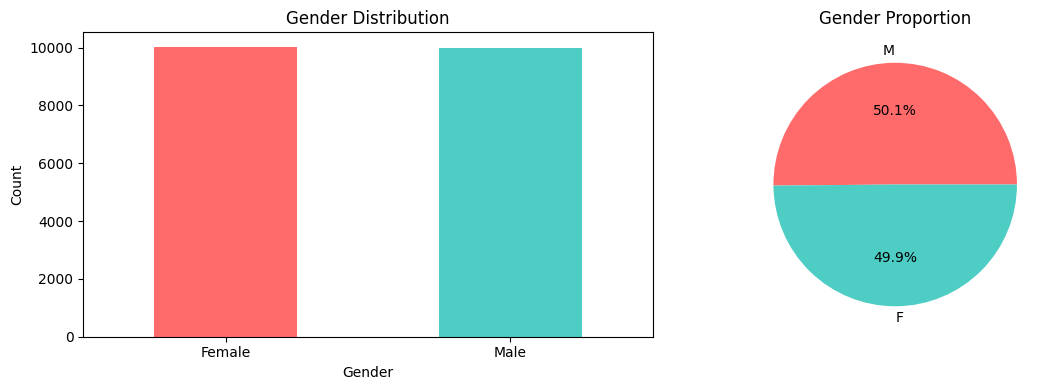

In [ ]:

print(data['Gender'].value_counts(normalize=True) * 100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data['Gender'].value_counts().plot(kind='bar', ax=ax[0], color=['#FF6B6B', '#4ECDC4'])
ax[0].set_title('Gender Distribution')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Female', 'Male'], rotation=0)

data['Gender'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
ax[1].set_ylabel('')
ax[1].set_title('Gender Proportion')
plt.tight_layout()
plt.show()

### 1.3 AGE

count    20000.000000
mean        31.422800
std          8.103717
min         18.000000
25%         24.000000
50%         31.000000
75%         39.000000
max         45.000000
Name: Age, dtype: float64

Age Groups:
Age_Group
18-25    5006
26-35    7180
36-45    7041
46+         0
Name: count, dtype: int64


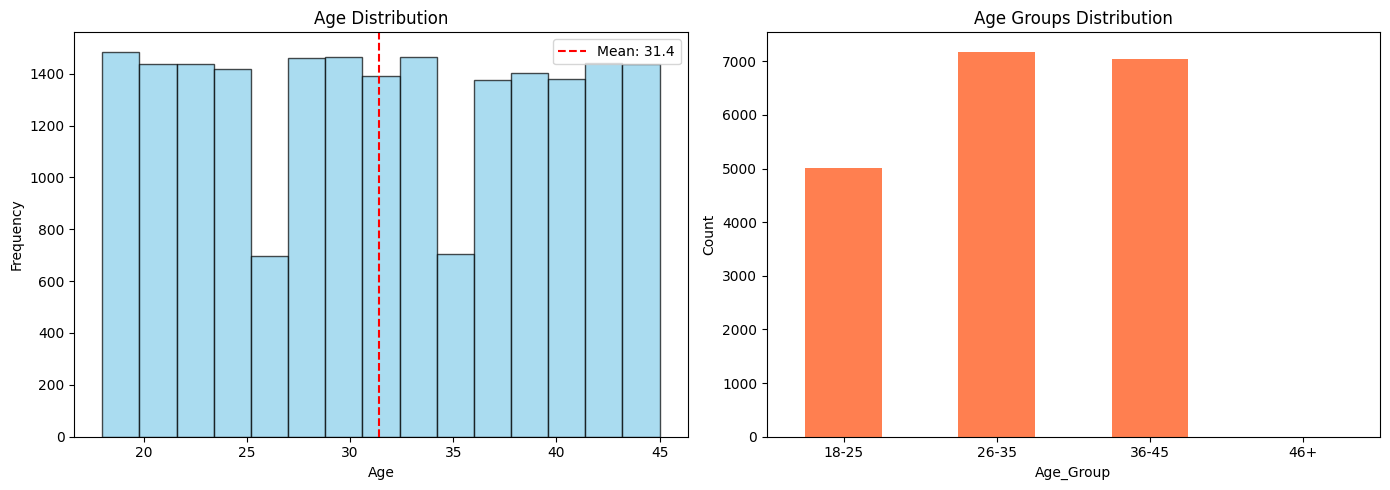

In [ ]:
print(data['Age'].describe())

# Tạo age groups
data['Age_Group'] = pd.cut(data['Age'], bins=[18, 25, 35, 45, 100],
                            labels=['18-25', '26-35', '36-45', '46+'])
print("\nAge Groups:")
print(data['Age_Group'].value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(data['Age'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Age Distribution')
ax[0].axvline(data['Age'].mean(), color='red', linestyle='--', label=f'Mean: {data["Age"].mean():.1f}')
ax[0].legend()

data['Age_Group'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color='coral')
ax[1].set_title('Age Groups Distribution')
ax[1].set_ylabel('Count')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét**: đa số là nằm trong độ tuổi lao động.

### 1.4 BMI

BMI Statistics:
count    20000.000000
mean        25.024844
std          6.570457
min         12.500000
25%         20.060954
50%         24.280264
75%         29.296875
max         44.444444
Name: BMI, dtype: float64

BMI Categories:
BMI_Category
Normal         7432
Overweight     4670
Obese          4459
Underweight    3439
Name: count, dtype: int64


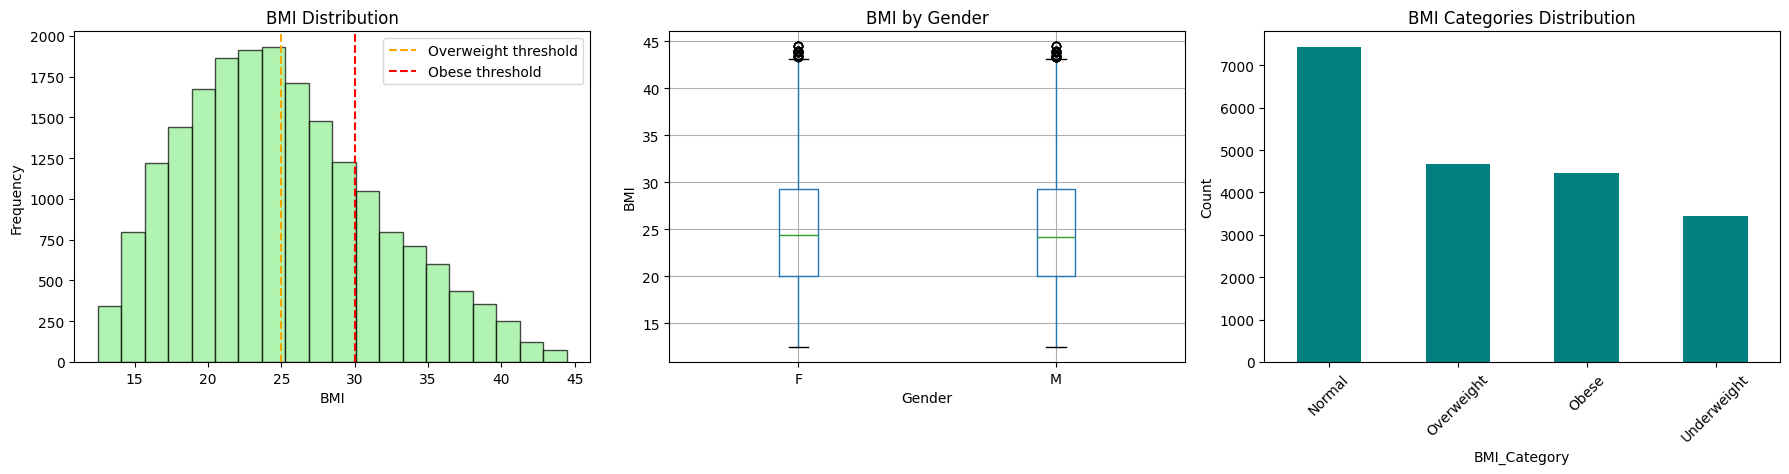

In [ ]:
data['BMI'] = data['Weight'] / ((data['Height'] / 100) ** 2)
print("BMI Statistics:")
print(data['BMI'].describe())

# BMI Categories (WHO)
data['BMI_Category'] = pd.cut(data['BMI'],
                               bins=[0, 18.5, 25, 30, 100],
                               labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print("\nBMI Categories:")
print(data['BMI_Category'].value_counts())

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].hist(data['BMI'], bins=20, edgecolor='black', color='lightgreen', alpha=0.7)
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Frequency')
ax[0].set_title('BMI Distribution')
ax[0].axvline(25, color='orange', linestyle='--', label='Overweight threshold')
ax[0].axvline(30, color='red', linestyle='--', label='Obese threshold')
ax[0].legend()

data.boxplot(column='BMI', by='Gender', ax=ax[1])
ax[1].set_title('BMI by Gender')
ax[1].set_xlabel('Gender')
ax[1].set_ylabel('BMI')
plt.suptitle('')

data['BMI_Category'].value_counts().plot(kind='bar', ax=ax[2], color='teal')
ax[2].set_title('BMI Categories Distribution')
ax[2].set_ylabel('Count')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

- Xu hướng chung: BMI trung bình (~25.02) và trung vị (~24.28) đều nằm ngay ngưỡng ranh giới giữa mức "Bình thường" và "Thừa cân".
- Tỷ lệ đáng báo động: Mặc dù nhóm "Normal" chiếm số lượng lớn nhất, nhưng tổng số người Thừa cân (Overweight) và Béo phì (Obese) cộng lại lên tới 9,129 người (chiếm ~45.6%). Điều này cho thấy gần một nửa mẫu khảo sát đang gặp vấn đề về cân nặng dư thừa.

###  1.5 BLOOD PRESSURE

Systolic BP:
count    20000.000000
mean       114.985450
std         14.725589
min         90.000000
25%        102.000000
50%        115.000000
75%        128.000000
max        140.000000
Name: Systolic, dtype: float64

Diastolic BP:
count    20000.000000
mean        74.999300
std          8.975034
min         60.000000
25%         67.000000
50%         75.000000
75%         83.000000
max         90.000000
Name: Diastolic, dtype: float64

BP Categories:
BP_Category
Hypertension Stage 1    9093
Normal                  7537
Elevated                2574
Hypertension Stage 2     796
Name: count, dtype: int64


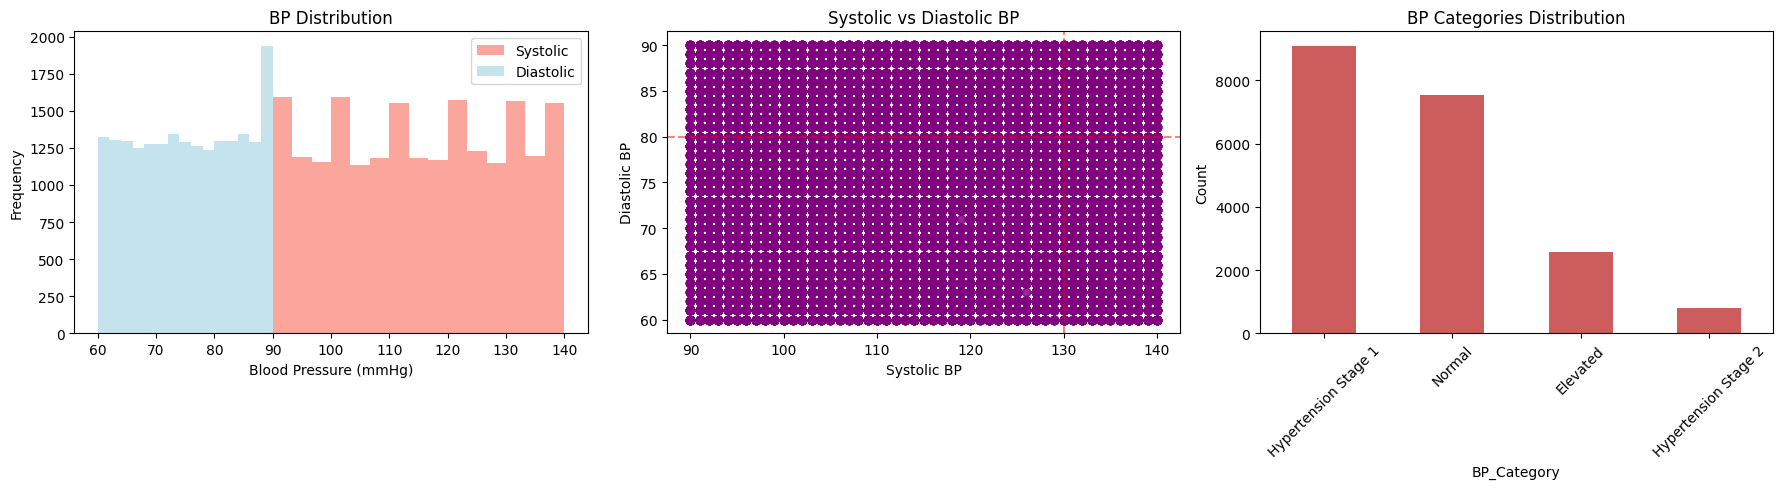

In [ ]:
data[['Systolic', 'Diastolic']] = data['Blood pressure'].str.split('/', expand=True).astype(int)
print("Systolic BP:")
print(data['Systolic'].describe())
print("\nDiastolic BP:")
print(data['Diastolic'].describe())

# BP Categories (AHA)
def classify_bp(row):
    systolic = row['Systolic']
    diastolic = row['Diastolic']
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif 120 <= systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif 130 <= systolic < 140 or 80 <= diastolic < 90:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

data['BP_Category'] = data.apply(classify_bp, axis=1)
print("\nBP Categories:")
print(data['BP_Category'].value_counts())

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].hist(data['Systolic'], bins=15, alpha=0.7, label='Systolic', color='salmon')
ax[0].hist(data['Diastolic'], bins=15, alpha=0.7, label='Diastolic', color='lightblue')
ax[0].set_xlabel('Blood Pressure (mmHg)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('BP Distribution')
ax[0].legend()

ax[1].scatter(data['Systolic'], data['Diastolic'], alpha=0.6, color='purple')
ax[1].set_xlabel('Systolic BP')
ax[1].set_ylabel('Diastolic BP')
ax[1].set_title('Systolic vs Diastolic BP')
ax[1].axhline(80, color='red', linestyle='--', alpha=0.5)
ax[1].axvline(130, color='red', linestyle='--', alpha=0.5)

data['BP_Category'].value_counts().plot(kind='bar', ax=ax[2], color='indianred')
ax[2].set_title('BP Categories Distribution')
ax[2].set_ylabel('Count')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

- Phản ánh dân số "Tiền tăng huyết áp": Nhóm Hypertension Stage 1 chiếm tỷ trọng lớn nhất (9,093 người - khoảng 45%), cao hơn cả nhóm "Bình thường". Điều này cho thấy phần lớn mẫu khảo sát đang ở ngưỡng huyết áp hơi cao so với tiêu chuẩn lý tưởng, dù chưa đến mức nguy hiểm (Stage 2 rất ít).
- Phân phối chuẩn mực: Cả Huyết áp tâm thu (Systolic) và tâm trương (Diastolic) đều có Mean xấp xỉ Median (115/75), cho thấy dữ liệu phân bố rất đều và đối xứng.
- Không có ca cực đoan: Giá trị Max dừng lại ở mức 140 (tâm thu) và 90 (tâm trương). Đây là ngưỡng bắt đầu của cao huyết áp giai đoạn 2. Việc không có các chỉ số cực cao (như 160-180+) cho thấy mẫu dữ liệu này khá "lành tính", phù hợp với độ tuổi trẻ/trung niên đã phân tích ở trên.

### 1.6 HEART RATE

count    20000.000000
mean        79.912200
std         11.808279
min         60.000000
25%         70.000000
50%         80.000000
75%         90.000000
max        100.000000
Name: Heart rate, dtype: float64

HR Categories:
HR_Category
Poor             5274
Below Average    4961
Good             4932
Average          4833
Name: count, dtype: int64


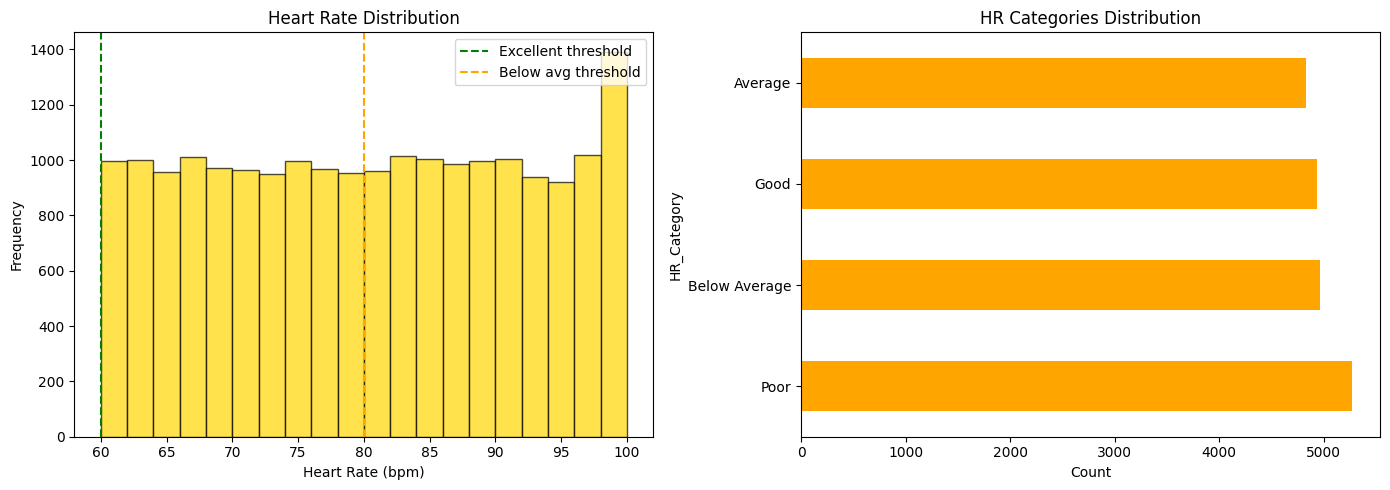

In [ ]:
print(data['Heart rate'].describe())

# HR Categories
def classify_hr(hr):
    if hr < 60:
        return 'Excellent'
    elif 60 <= hr < 70:
        return 'Good'
    elif 70 <= hr < 80:
        return 'Average'
    elif 80 <= hr < 90:
        return 'Below Average'
    else:
        return 'Poor'

data['HR_Category'] = data['Heart rate'].apply(classify_hr)
print("\nHR Categories:")
print(data['HR_Category'].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(data['Heart rate'], bins=20, edgecolor='black', color='gold', alpha=0.7)
ax[0].set_xlabel('Heart Rate (bpm)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Heart Rate Distribution')
ax[0].axvline(60, color='green', linestyle='--', label='Excellent threshold')
ax[0].axvline(80, color='orange', linestyle='--', label='Below avg threshold')
ax[0].legend()

data['HR_Category'].value_counts().plot(kind='barh', ax=ax[1], color='orange')
ax[1].set_title('HR Categories Distribution')
ax[1].set_xlabel('Count')
plt.tight_layout()
plt.show()


- Phân phối "phẳng" (Uniform): Điểm đặc biệt nhất là sự phân bố cực kỳ đồng đều giữa 4 nhóm phân loại (mỗi nhóm ~25%, khoảng 5,000 người). Điều này (cùng với histogram phẳng) cho thấy dữ liệu nhịp tim có khả năng cao là dữ liệu giả lập (synthetic) hoặc đã được lấy mẫu theo quy hoạch định sẵn, vì dữ liệu sinh học tự nhiên thường sẽ phân phối theo hình chuông (Normal distribution) tụ tập quanh giá trị trung bình.
- Ý nghĩa phân tích: Vì sự phân bố quá đều này, biến số Nhịp tim trong tập dữ liệu này có thể sẽ không mang nhiều tính phân loại mạnh mẽ (discriminative power) khi chạy mô hình dự đoán, trừ khi có mối tương quan phi tuyến tính rõ rệt với bệnh.

## PRASE 3. PHÂN TÍCH VỚI DED (BIVARIATE)

### 1.7 GENDER - DED

In [ ]:
# Helper function for chi-square test and odds ratio
def chi_square_analysis(data, var1, var2='Dry Eye Disease'):
    """Perform chi-square test and calculate odds ratio"""
    ct = pd.crosstab(data[var1], data[var2])
    print(f"\nContingency Table - {var1} vs {var2}:")
    print(ct)

    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"\nChi-square test: χ² = {chi2:.4f}, p-value = {p:.4f}")

    if ct.shape == (2, 2):
        # Calculate Odds Ratio for 2x2 table
        a, b = ct.iloc[0, 0], ct.iloc[0, 1]
        c, d = ct.iloc[1, 0], ct.iloc[1, 1]
        or_value = (b * c) / (a * d) if (a * d) != 0 else np.nan

        # 95% CI for OR
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d) if min(a,b,c,d) > 0 else np.nan
        ci_lower = np.exp(np.log(or_value) - 1.96 * se_log_or)
        ci_upper = np.exp(np.log(or_value) + 1.96 * se_log_or)

        print(f"Odds Ratio: {or_value:.4f} (95% CI: {ci_lower:.4f} - {ci_upper:.4f})")

    return ct, chi2, p


Contingency Table - Gender vs Dry Eye Disease:
Dry Eye Disease     N     Y
Gender                     
F                3394  6578
M                3569  6459

Chi-square test: χ² = 5.2594, p-value = 0.0218
Odds Ratio: 1.0709 (95% CI: 1.0104 - 1.1351)


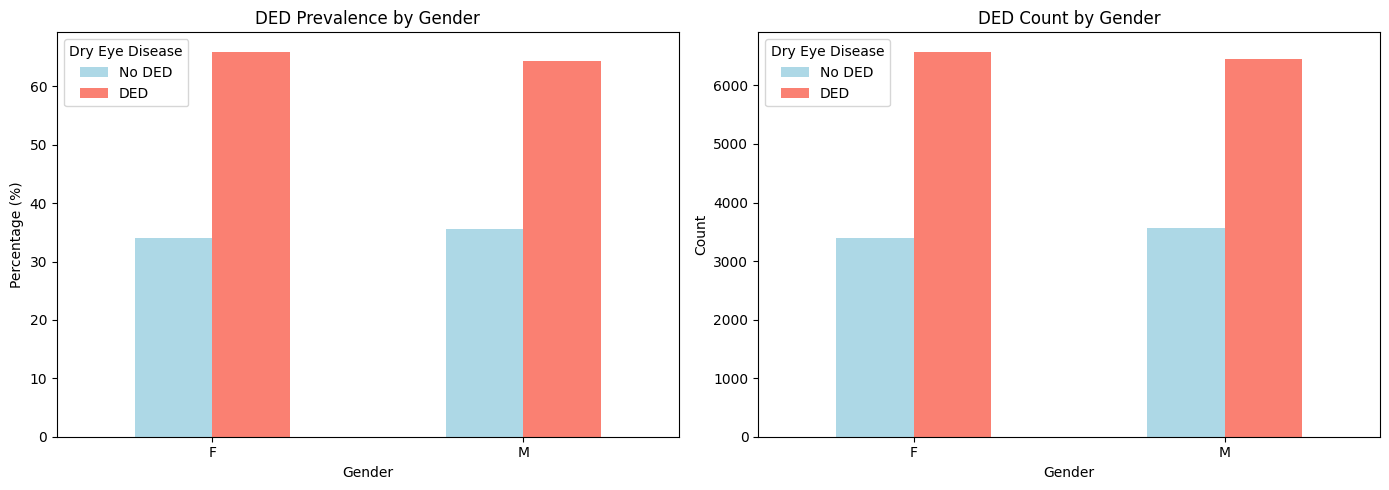

In [ ]:
ct_gender, chi2_gender, p_gender = chi_square_analysis(data, 'Gender')

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ct_pct = ct_gender.div(ct_gender.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=False, ax=ax[0], color=['lightblue', 'salmon'])
ax[0].set_title('DED Prevalence by Gender')
ax[0].set_ylabel('Percentage (%)')
ax[0].set_xlabel('Gender')
ax[0].legend(['No DED', 'DED'], title='Dry Eye Disease')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Count table
ct_gender.plot(kind='bar', ax=ax[1], color=['lightblue', 'salmon'])
ax[1].set_title('DED Count by Gender')
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Gender')
ax[1].legend(['No DED', 'DED'], title='Dry Eye Disease')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.8 AGE - DED


Age - DED=Y: Mean=31.45, Median=31.00
Age - DED=N: Mean=31.36, Median=31.00

T-test: t=0.7436, p-value=0.4571
Cohen's d: 0.0110

Contingency Table - Age_Group vs Dry Eye Disease:
Dry Eye Disease     N     Y
Age_Group                  
18-25            1736  3270
26-35            2552  4628
36-45            2424  4617

Chi-square test: χ² = 2.1081, p-value = 0.3485


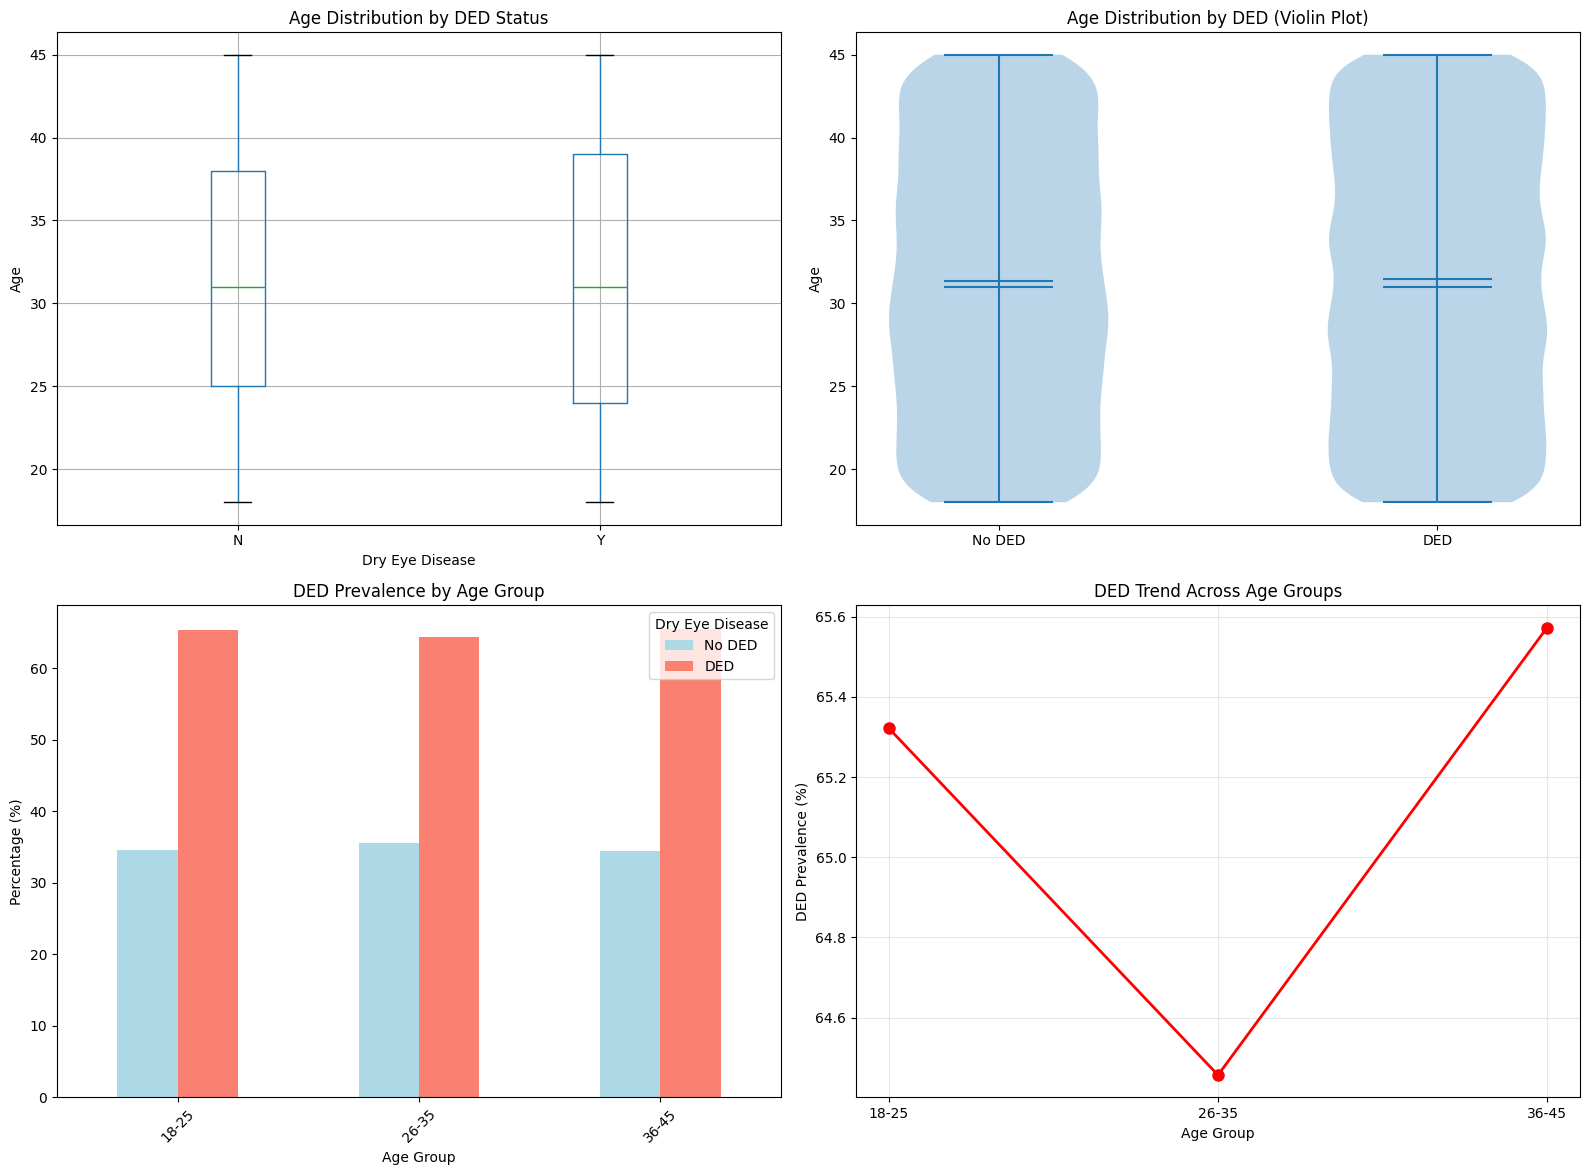

In [ ]:
# Continuous analysis
age_ded_y = data[data['Dry Eye Disease'] == 'Y']['Age']
age_ded_n = data[data['Dry Eye Disease'] == 'N']['Age']

print(f"\nAge - DED=Y: Mean={age_ded_y.mean():.2f}, Median={age_ded_y.median():.2f}")
print(f"Age - DED=N: Mean={age_ded_n.mean():.2f}, Median={age_ded_n.median():.2f}")

# T-test
t_stat, p_val = ttest_ind(age_ded_y, age_ded_n)
print(f"\nT-test: t={t_stat:.4f}, p-value={p_val:.4f}")

# Cohen's d (effect size)
cohens_d = (age_ded_y.mean() - age_ded_n.mean()) / np.sqrt(((len(age_ded_y)-1)*age_ded_y.std()**2 + (len(age_ded_n)-1)*age_ded_n.std()**2) / (len(age_ded_y) + len(age_ded_n) - 2))
print(f"Cohen's d: {cohens_d:.4f}")

# Categorical analysis
ct_age, chi2_age, p_age = chi_square_analysis(data, 'Age_Group')

# Visualization
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
data.boxplot(column='Age', by='Dry Eye Disease', ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution by DED Status')
ax[0, 0].set_xlabel('Dry Eye Disease')
ax[0, 0].set_ylabel('Age')
plt.suptitle('')

# Violin plot
parts = ax[0, 1].violinplot([age_ded_n, age_ded_y], positions=[0, 1], showmeans=True, showmedians=True)
ax[0, 1].set_xticks([0, 1])
ax[0, 1].set_xticklabels(['No DED', 'DED'])
ax[0, 1].set_ylabel('Age')
ax[0, 1].set_title('Age Distribution by DED (Violin Plot)')

# Grouped bar by age group
ct_age_pct = ct_age.div(ct_age.sum(axis=1), axis=0) * 100
ct_age_pct.plot(kind='bar', ax=ax[1, 0], color=['lightblue', 'salmon'])
ax[1, 0].set_title('DED Prevalence by Age Group')
ax[1, 0].set_ylabel('Percentage (%)')
ax[1, 0].set_xlabel('Age Group')
ax[1, 0].legend(['No DED', 'DED'], title='Dry Eye Disease')
ax[1, 0].set_xticklabels(ax[1, 0].get_xticklabels(), rotation=45)

# Line plot - trend
ded_by_age = ct_age_pct['Y']
ax[1, 1].plot(ded_by_age.index, ded_by_age.values, marker='o', linewidth=2, markersize=8, color='red')
ax[1, 1].set_xlabel('Age Group')
ax[1, 1].set_ylabel('DED Prevalence (%)')
ax[1, 1].set_title('DED Trend Across Age Groups')
ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.9 BMI - DED


BMI - DED=Y: Mean=25.06, Median=24.30
BMI - DED=N: Mean=24.96, Median=24.25

T-test: t=1.0190, p-value=0.3082

Contingency Table - BMI_Category vs Dry Eye Disease:
Dry Eye Disease     N     Y
BMI_Category               
Underweight      1164  2275
Normal           2654  4778
Overweight       1642  3028
Obese            1503  2956

Chi-square test: χ² = 6.7031, p-value = 0.0820


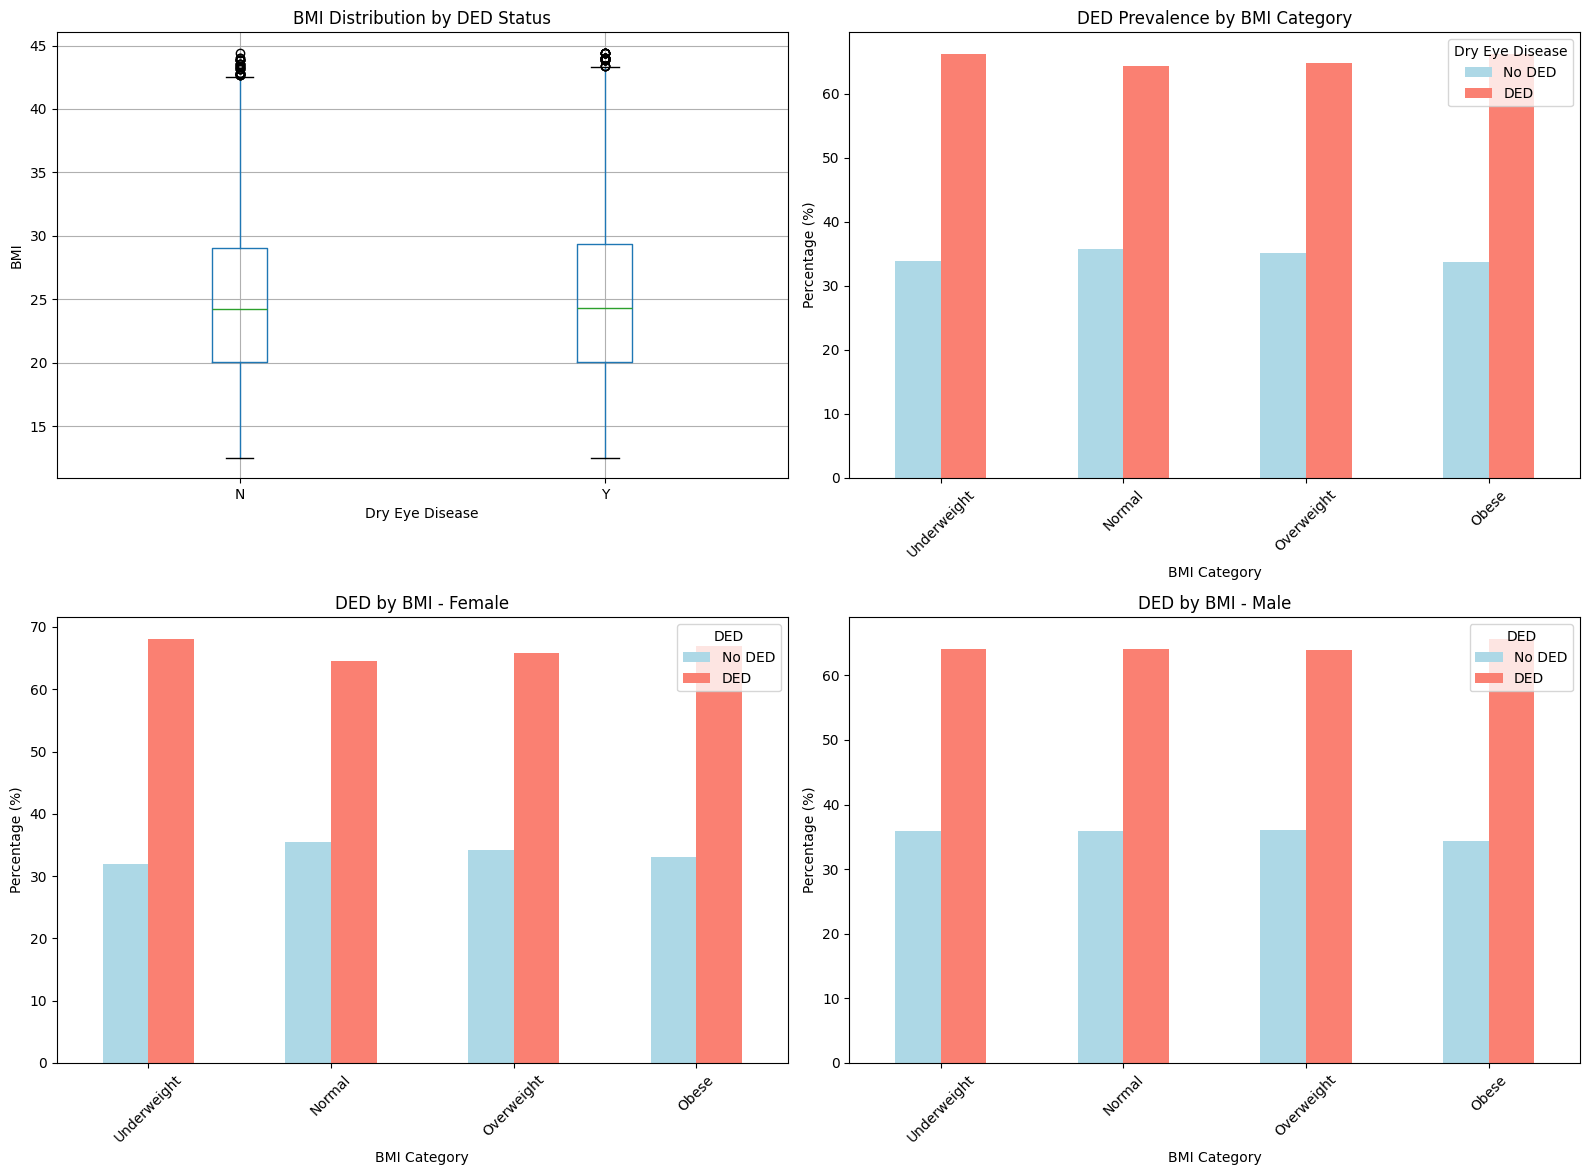

In [ ]:
# Continuous analysis
bmi_ded_y = data[data['Dry Eye Disease'] == 'Y']['BMI']
bmi_ded_n = data[data['Dry Eye Disease'] == 'N']['BMI']

print(f"\nBMI - DED=Y: Mean={bmi_ded_y.mean():.2f}, Median={bmi_ded_y.median():.2f}")
print(f"BMI - DED=N: Mean={bmi_ded_n.mean():.2f}, Median={bmi_ded_n.median():.2f}")

t_stat_bmi, p_val_bmi = ttest_ind(bmi_ded_y, bmi_ded_n)
print(f"\nT-test: t={t_stat_bmi:.4f}, p-value={p_val_bmi:.4f}")

# Categorical analysis
ct_bmi, chi2_bmi, p_bmi = chi_square_analysis(data, 'BMI_Category')

# Visualization
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

data.boxplot(column='BMI', by='Dry Eye Disease', ax=ax[0, 0])
ax[0, 0].set_title('BMI Distribution by DED Status')
ax[0, 0].set_xlabel('Dry Eye Disease')
ax[0, 0].set_ylabel('BMI')
plt.suptitle('')

ct_bmi_pct = ct_bmi.div(ct_bmi.sum(axis=1), axis=0) * 100
ct_bmi_pct.plot(kind='bar', ax=ax[0, 1], color=['lightblue', 'salmon'])
ax[0, 1].set_title('DED Prevalence by BMI Category')
ax[0, 1].set_ylabel('Percentage (%)')
ax[0, 1].set_xlabel('BMI Category')
ax[0, 1].legend(['No DED', 'DED'], title='Dry Eye Disease')
ax[0, 1].set_xticklabels(ax[0, 1].get_xticklabels(), rotation=45)

# Faceted by gender
for i, gender in enumerate(['F', 'M']):
    subset = data[data['Gender'] == gender]
    ct_subset = pd.crosstab(subset['BMI_Category'], subset['Dry Eye Disease'])
    ct_subset_pct = ct_subset.div(ct_subset.sum(axis=1), axis=0) * 100
    ct_subset_pct.plot(kind='bar', ax=ax[1, i], color=['lightblue', 'salmon'])
    ax[1, i].set_title(f'DED by BMI - {"Female" if gender=="F" else "Male"}')
    ax[1, i].set_ylabel('Percentage (%)')
    ax[1, i].set_xlabel('BMI Category')
    ax[1, i].legend(['No DED', 'DED'], title='DED')
    ax[1, i].set_xticklabels(ax[1, i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 1.10 BLOOD PRESSURE - DED


Systolic - DED=Y: 115.06, DED=N: 114.84
Diastolic - DED=Y: 74.97, DED=N: 75.06

Systolic t-test: t=1.0309, p=0.3026
Diastolic t-test: t=-0.7142, p=0.4751

Contingency Table - BP_Category vs Dry Eye Disease:
Dry Eye Disease          N     Y
BP_Category                     
Elevated               923  1651
Hypertension Stage 1  3109  5984
Hypertension Stage 2   271   525
Normal                2660  4877

Chi-square test: χ² = 3.7599, p-value = 0.2886


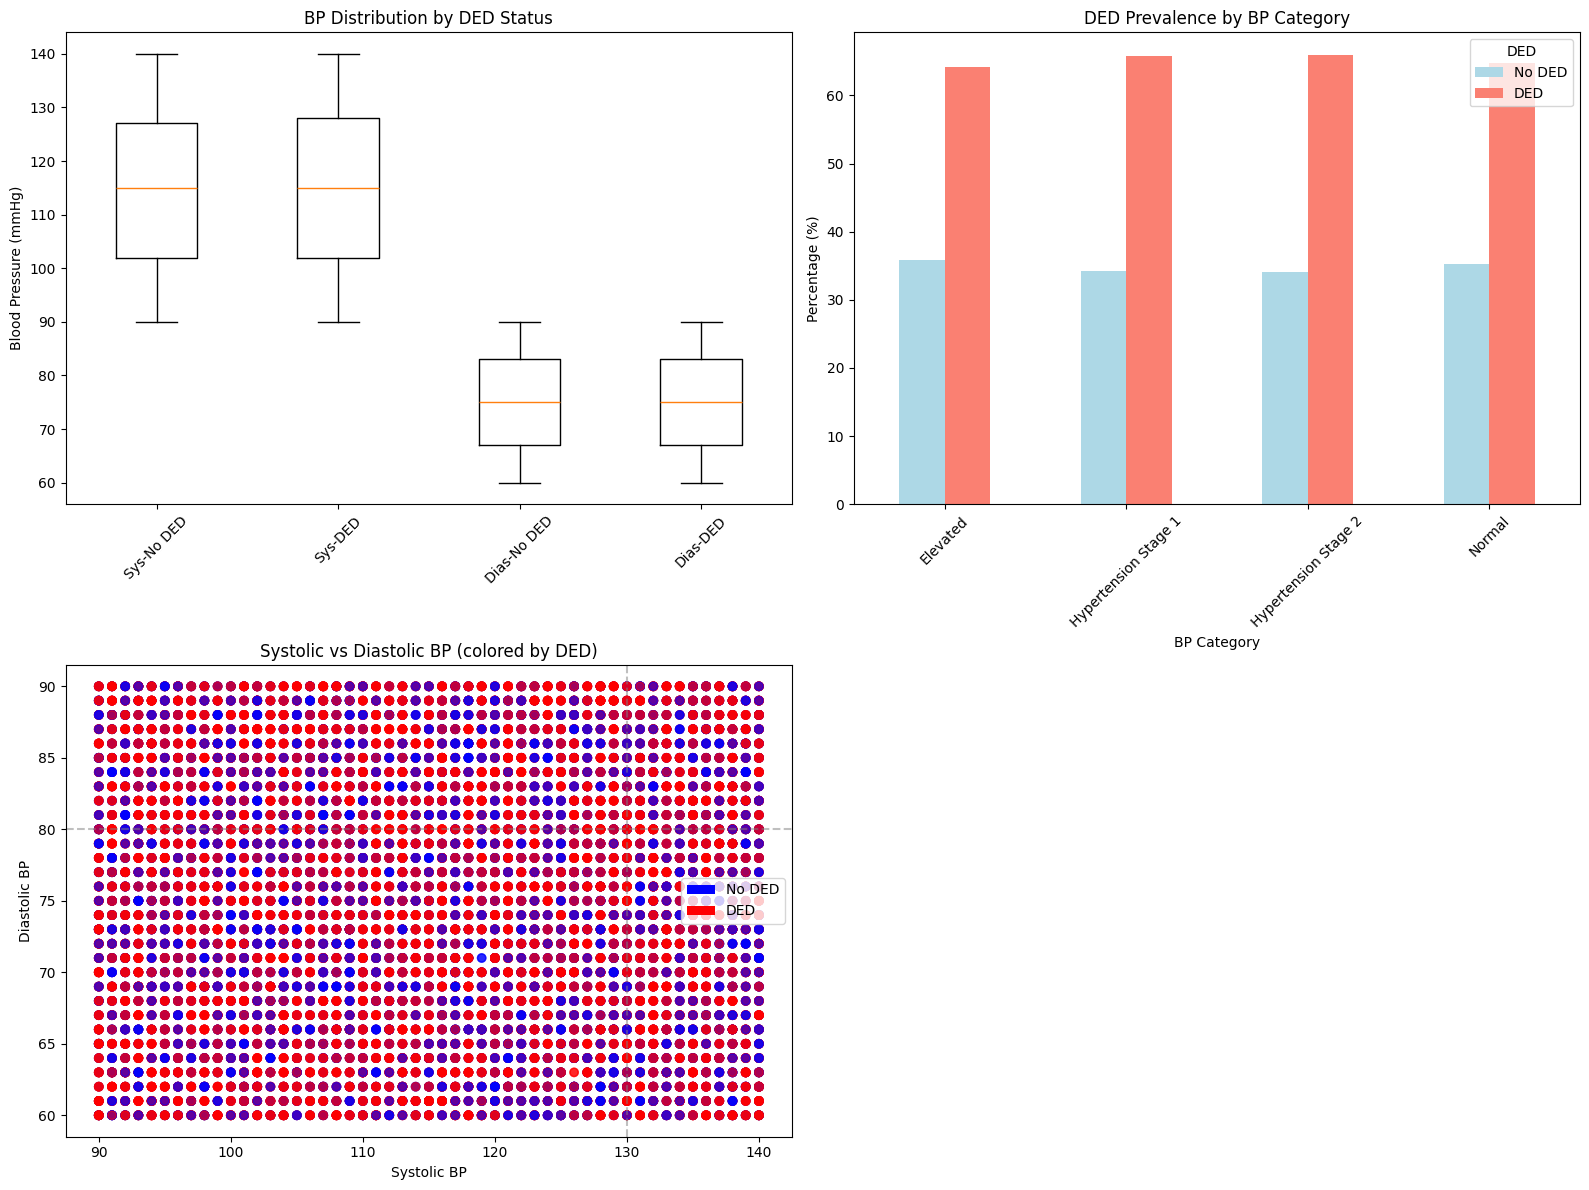

In [ ]:
# Continuous
sys_ded_y = data[data['Dry Eye Disease'] == 'Y']['Systolic']
sys_ded_n = data[data['Dry Eye Disease'] == 'N']['Systolic']
dias_ded_y = data[data['Dry Eye Disease'] == 'Y']['Diastolic']
dias_ded_n = data[data['Dry Eye Disease'] == 'N']['Diastolic']

print(f"\nSystolic - DED=Y: {sys_ded_y.mean():.2f}, DED=N: {sys_ded_n.mean():.2f}")
print(f"Diastolic - DED=Y: {dias_ded_y.mean():.2f}, DED=N: {dias_ded_n.mean():.2f}")

t_sys, p_sys = ttest_ind(sys_ded_y, sys_ded_n)
t_dias, p_dias = ttest_ind(dias_ded_y, dias_ded_n)
print(f"\nSystolic t-test: t={t_sys:.4f}, p={p_sys:.4f}")
print(f"Diastolic t-test: t={t_dias:.4f}, p={p_dias:.4f}")

# Categorical
ct_bp, chi2_bp, p_bp = chi_square_analysis(data, 'BP_Category')

# Visualization
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

bp_data = [sys_ded_n, sys_ded_y, dias_ded_n, dias_ded_y]
bp_labels = ['Sys-No DED', 'Sys-DED', 'Dias-No DED', 'Dias-DED']
ax[0, 0].boxplot(bp_data, labels=bp_labels)
ax[0, 0].set_ylabel('Blood Pressure (mmHg)')
ax[0, 0].set_title('BP Distribution by DED Status')
ax[0, 0].tick_params(axis='x', rotation=45)

ct_bp_pct = ct_bp.div(ct_bp.sum(axis=1), axis=0) * 100
ct_bp_pct.plot(kind='bar', ax=ax[0, 1], color=['lightblue', 'salmon'])
ax[0, 1].set_title('DED Prevalence by BP Category')
ax[0, 1].set_ylabel('Percentage (%)')
ax[0, 1].set_xlabel('BP Category')
ax[0, 1].legend(['No DED', 'DED'], title='DED')
ax[0, 1].set_xticklabels(ax[0, 1].get_xticklabels(), rotation=45)

# Scatter plot colored by DED
colors = data['Dry Eye Disease'].map({'N': 'blue', 'Y': 'red'})
ax[1, 0].scatter(data['Systolic'], data['Diastolic'], c=colors, alpha=0.6)
ax[1, 0].set_xlabel('Systolic BP')
ax[1, 0].set_ylabel('Diastolic BP')
ax[1, 0].set_title('Systolic vs Diastolic BP (colored by DED)')
ax[1, 0].axhline(80, color='gray', linestyle='--', alpha=0.5)
ax[1, 0].axvline(130, color='gray', linestyle='--', alpha=0.5)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='No DED'), Patch(facecolor='red', label='DED')]
ax[1, 0].legend(handles=legend_elements)

ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

- Hoàn toàn không có liên hệ: Cả huyết áp tâm thu, tâm trương và các nhóm phân loại huyết áp đều không cho thấy mối liên hệ nào với bệnh Khô mắt.
Số liệu chứng minh:
- T-test: Điểm trung bình huyết áp giữa nhóm Bị bệnh (Y) và Không bị bệnh (N) gần như trùng khít nhau (chênh lệch chưa đến 0.2 mmHg). P-value rất lớn (> 0.3) xác nhận sự chênh lệch này chẳng có ý nghĩa gì.
- Chi-square: P-value ~ 0.29 cũng cho thấy việc phân loại người dùng vào các nhóm huyết áp khác nhau không giúp dự đoán được khả năng mắc bệnh.
Hệ quả: Trong bước xây dựng mô hình dự đoán (Data Modeling) sắp tới, biến số Huyết áp là một ứng cử viên sáng giá để loại bỏ (feature selection) nhằm giảm nhiễu, vì nó không mang lại giá trị phân loại.

### 1.11 HEART RATE - DED


HR - DED=Y: 79.89, DED=N: 79.95

T-test: t=-0.2946, p=0.7683

Contingency Table - HR_Category vs Dry Eye Disease:
Dry Eye Disease     N     Y
HR_Category                
Average          1667  3166
Below Average    1708  3253
Good             1728  3204
Poor             1860  3414

Chi-square test: χ² = 1.1308, p-value = 0.7697


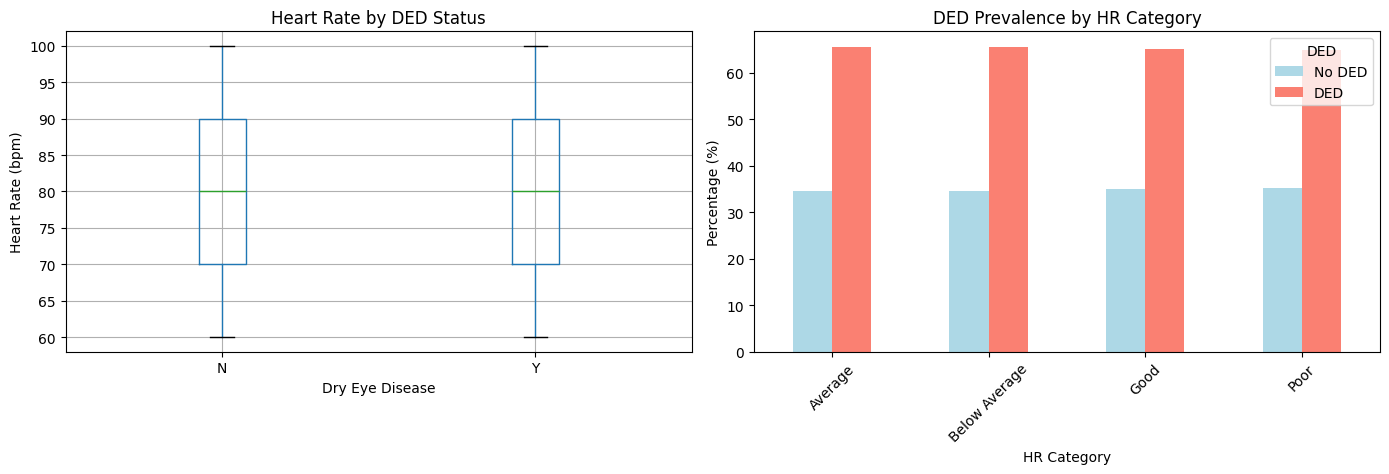

In [ ]:
hr_ded_y = data[data['Dry Eye Disease'] == 'Y']['Heart rate']
hr_ded_n = data[data['Dry Eye Disease'] == 'N']['Heart rate']

print(f"\nHR - DED=Y: {hr_ded_y.mean():.2f}, DED=N: {hr_ded_n.mean():.2f}")

t_hr, p_hr = ttest_ind(hr_ded_y, hr_ded_n)
print(f"\nT-test: t={t_hr:.4f}, p={p_hr:.4f}")

ct_hr, chi2_hr, p_hr_cat = chi_square_analysis(data, 'HR_Category')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

data.boxplot(column='Heart rate', by='Dry Eye Disease', ax=ax[0])
ax[0].set_title('Heart Rate by DED Status')
ax[0].set_xlabel('Dry Eye Disease')
ax[0].set_ylabel('Heart Rate (bpm)')
plt.suptitle('')

ct_hr_pct = ct_hr.div(ct_hr.sum(axis=1), axis=0) * 100
ct_hr_pct.plot(kind='bar', ax=ax[1], color=['lightblue', 'salmon'])
ax[1].set_title('DED Prevalence by HR Category')
ax[1].set_ylabel('Percentage (%)')
ax[1].set_xlabel('HR Category')
ax[1].legend(['No DED', 'DED'], title='DED')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()



Các kết quả thống kê khẳng định chắc chắn rằng Nhịp tim không có bất kỳ liên hệ nào với bệnh Khô mắt trong tập dữ liệu này.

## PRASE 4: PHÂN TÍCH TỔNG HỢP

### 1.12 CORRELATION MATRIX

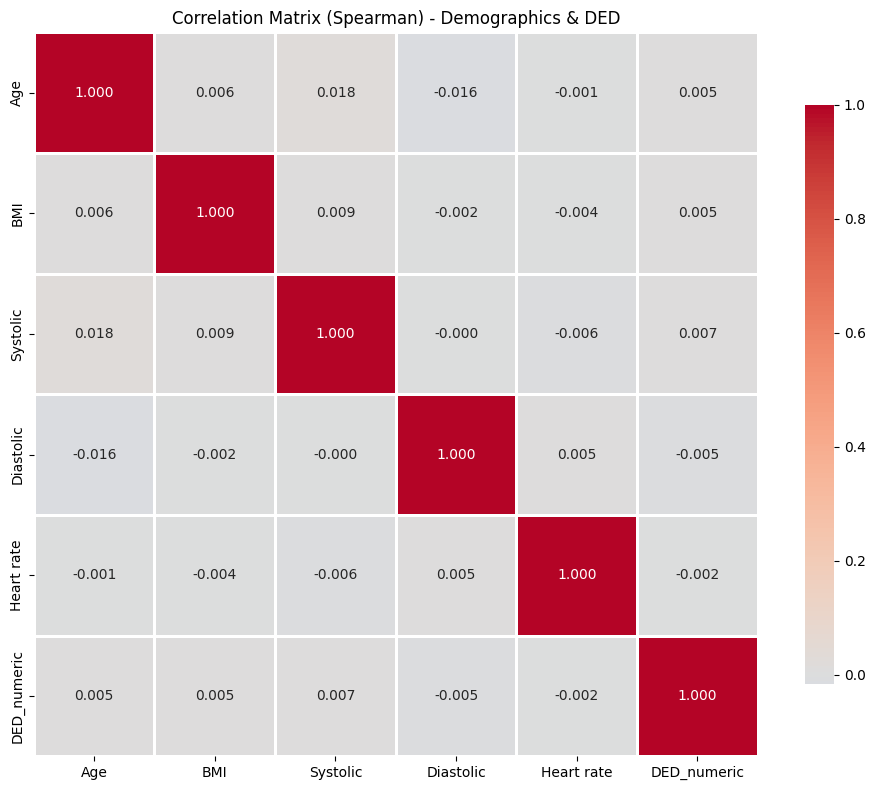


Correlation with DED:
DED_numeric    1.000000
Systolic       0.007306
Age            0.005152
BMI            0.004869
Heart rate    -0.002128
Diastolic     -0.005068
Name: DED_numeric, dtype: float64


In [ ]:
corr_vars = ['Age', 'BMI', 'Systolic', 'Diastolic', 'Heart rate']
data['DED_numeric'] = data['Dry Eye Disease'].map({'N': 0, 'Y': 1})
corr_data = data[corr_vars + ['DED_numeric']]
corr_matrix = corr_data.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Spearman) - Demographics & DED')
plt.tight_layout()
plt.show()

print("\nCorrelation with DED:")
print(corr_matrix['DED_numeric'].sort_values(ascending=False))

Tương quan bằng 0: Tất cả các hệ số tương quan đều vô cùng nhỏ (< 0.01), gần như bằng 0 tuyệt đối. Không có bất kỳ biến số nào trong nhóm Nhân khẩu học & Sinh trắc (Tuổi, BMI, Huyết áp, Nhịp tim) có mối quan hệ tuyến tính với bệnh Khô mắt. :)))

### 1.13 RISK SUMMARY TABLE

In [ ]:
risk_summary = []

# Function to calculate OR from contingency table
def calc_or_from_ct(ct):
    if ct.shape == (2, 2):
        a, b = ct.iloc[0, 0], ct.iloc[0, 1]
        c, d = ct.iloc[1, 0], ct.iloc[1, 1]
        or_val = (b * c) / (a * d) if (a * d) != 0 else np.nan
        se_log = np.sqrt(1/a + 1/b + 1/c + 1/d) if min(a,b,c,d) > 0 else np.nan
        ci_lower = np.exp(np.log(or_val) - 1.96 * se_log) if not np.isnan(se_log) else np.nan
        ci_upper = np.exp(np.log(or_val) + 1.96 * se_log) if not np.isnan(se_log) else np.nan
        return or_val, ci_lower, ci_upper
    return np.nan, np.nan, np.nan

# Gender
ct_gender_risk = pd.crosstab(data['Gender'], data['Dry Eye Disease'])
or_gender, ci_l_gender, ci_u_gender = calc_or_from_ct(ct_gender_risk)
ded_n_gender = ct_gender_risk.loc[:, 'N'].sum()
ded_y_gender = ct_gender_risk.loc[:, 'Y'].sum()

# Age >=40
data['Age_40plus'] = (data['Age'] >= 40).astype(int)
ct_age40 = pd.crosstab(data['Age_40plus'], data['Dry Eye Disease'])
or_age40, ci_l_age40, ci_u_age40 = calc_or_from_ct(ct_age40)

# BMI >=25
data['BMI_25plus'] = (data['BMI'] >= 25).astype(int)
ct_bmi25 = pd.crosstab(data['BMI_25plus'], data['Dry Eye Disease'])
or_bmi25, ci_l_bmi25, ci_u_bmi25 = calc_or_from_ct(ct_bmi25)

# Hypertension (Stage 1 or 2)
data['Hypertension'] = data['BP_Category'].isin(['Hypertension Stage 1', 'Hypertension Stage 2']).astype(int)
ct_hyper = pd.crosstab(data['Hypertension'], data['Dry Eye Disease'])
or_hyper, ci_l_hyper, ci_u_hyper = calc_or_from_ct(ct_hyper)

# HR >=80
data['HR_80plus'] = (data['Heart rate'] >= 80).astype(int)
ct_hr80 = pd.crosstab(data['HR_80plus'], data['Dry Eye Disease'])
or_hr80, ci_l_hr80, ci_u_hr80 = calc_or_from_ct(ct_hr80)

# Create summary table
risk_summary_df = pd.DataFrame({
    'Risk Factor': ['Gender (Female vs Male)', 'Age ≥40', 'BMI ≥25 (Overweight/Obese)',
                    'Hypertension (Stage 1/2)', 'Heart Rate ≥80'],
    'DED=N': [ct_gender_risk.loc['F', 'N'], ct_age40.loc[1, 'N'] if 1 in ct_age40.index else 0,
              ct_bmi25.loc[1, 'N'] if 1 in ct_bmi25.index else 0,
              ct_hyper.loc[1, 'N'] if 1 in ct_hyper.index else 0,
              ct_hr80.loc[1, 'N'] if 1 in ct_hr80.index else 0],
    'DED=Y': [ct_gender_risk.loc['F', 'Y'], ct_age40.loc[1, 'Y'] if 1 in ct_age40.index else 0,
              ct_bmi25.loc[1, 'Y'] if 1 in ct_bmi25.index else 0,
              ct_hyper.loc[1, 'Y'] if 1 in ct_hyper.index else 0,
              ct_hr80.loc[1, 'Y'] if 1 in ct_hr80.index else 0],
    'OR': [or_gender, or_age40, or_bmi25, or_hyper, or_hr80],
    '95% CI Lower': [ci_l_gender, ci_l_age40, ci_l_bmi25, ci_l_hyper, ci_l_hr80],
    '95% CI Upper': [ci_u_gender, ci_u_age40, ci_u_bmi25, ci_u_hyper, ci_u_hr80],
    'p-value': [p_gender, p_age, p_bmi, p_bp, p_hr_cat]
})

print(risk_summary_df.to_string(index=False))

               Risk Factor  DED=N  DED=Y       OR  95% CI Lower  95% CI Upper  p-value
   Gender (Female vs Male)   3394   6578 1.070935      1.010388      1.135111 0.021828
                   Age ≥40   1434   2826 0.937127      0.872480      1.006565 0.348524
BMI ≥25 (Overweight/Obese)   3148   5989 0.971073      0.915961      1.029501 0.081989
  Hypertension (Stage 1/2)   3380   6509 0.946097      0.892605      1.002796 0.288579
            Heart Rate ≥80   3568   6667 1.004139      0.947364      1.064317 0.769654


- Giới tính là yếu tố duy nhất có ý nghĩa: Chỉ có sự khác biệt về giới tính (Nữ so với Nam) là có ý nghĩa thống kê (p < 0.05). Tuy nhiên, với OR = 1.07, mức độ gia tăng nguy cơ là rất thấp.
- Các "nguy cơ" kinh điển đều vô hiệu: Tất cả các giả thuyết về sức khỏe thể chất như Tuổi cao (≥40), Thừa cân (BMI≥25), Tăng huyết áp hay Nhịp tim đều bị bác bỏ hoàn toàn. Chúng không làm tăng nguy cơ mắc bệnh Khô mắt trong tập dữ liệu này (khoảng tin cậy đều chứa số 1 và p-value > 0.05).a

### 1.14 Forest Plot - Odds Ratios with 95% CI

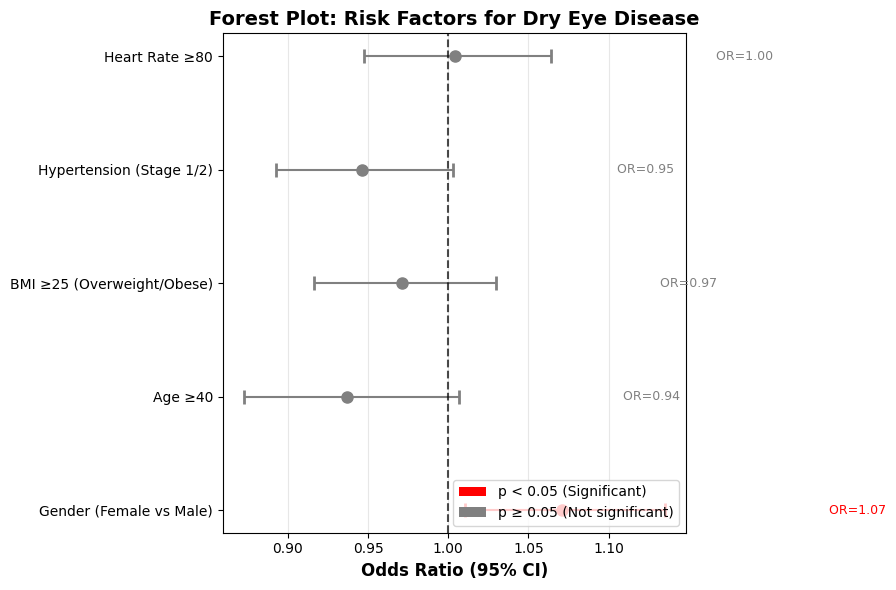

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

factors = risk_summary_df['Risk Factor'].tolist()
ors = risk_summary_df['OR'].tolist()
ci_lowers = risk_summary_df['95% CI Lower'].tolist()
ci_uppers = risk_summary_df['95% CI Upper'].tolist()
p_values = risk_summary_df['p-value'].tolist()

y_pos = np.arange(len(factors))

# Plot points and error bars
for i in range(len(factors)):
    color = 'red' if p_values[i] < 0.05 else 'gray'
    ax.errorbar(ors[i], y_pos[i], xerr=[[ors[i]-ci_lowers[i]], [ci_uppers[i]-ors[i]]],
                fmt='o', color=color, ecolor=color, capsize=5, capthick=2, markersize=8)

    # Add OR value text
    ax.text(ci_uppers[i] + 0.1, y_pos[i], f' OR={ors[i]:.2f}', va='center', fontsize=9, color=color)

# Reference line at OR=1
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='OR=1 (No effect)')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(factors)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
ax.set_title('Forest Plot: Risk Factors for Dry Eye Disease', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add significance legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='p < 0.05 (Significant)'),
                   Patch(facecolor='gray', label='p ≥ 0.05 (Not significant)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

chỉ có giới tính là có ý nghĩa còn lại là vô hiệu (màu xám)

# PHẦN 2: SỨC KHỎE GIẤC NGỦ VÀ TÂM LÝ

## PRASE 1: PHÂN TÍCH ĐƠN BIẾN

### 2.1 SLEEP DURATION

Sleep Duration Categories:
Sleep_Duration_Cat
Severe Lack (<5h)    3124
Lack (5-7h)          6720
Normal (7-9h)        6595
Excess (>9h)         3561
Name: count, dtype: int64


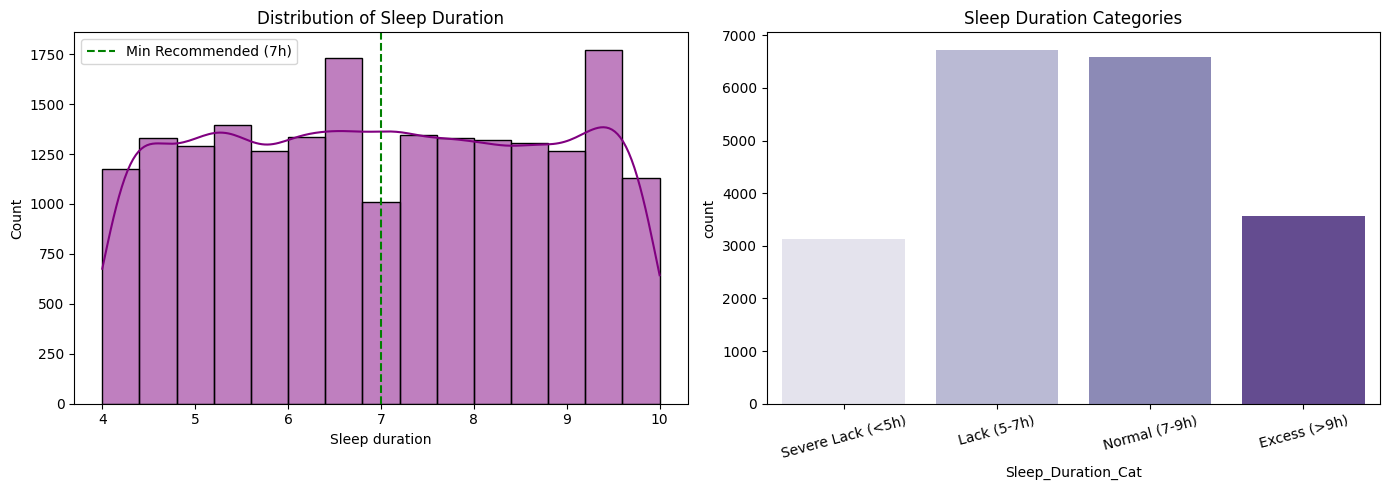

In [ ]:
# Categorize Sleep Duration
# <5: Severe Lack, 5-7: Lack, 7-9: Normal, >9: Excess
data['Sleep_Duration_Cat'] = pd.cut(data['Sleep duration'],
                                    bins=[0, 5, 7, 9, 24],
                                    labels=['Severe Lack (<5h)', 'Lack (5-7h)', 'Normal (7-9h)', 'Excess (>9h)'],
                                    right=False) # right=False means [0, 5), [5, 7)...

print("Sleep Duration Categories:")
print(data['Sleep_Duration_Cat'].value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['Sleep duration'], bins=15, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribution of Sleep Duration')
ax[0].axvline(7, color='green', linestyle='--', label='Min Recommended (7h)')
ax[0].legend()

sns.countplot(x='Sleep_Duration_Cat', data=data, ax=ax[1], palette='Purples')
ax[1].set_title('Sleep Duration Categories')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()


- Tình trạng thiếu ngủ phổ biến: Gần một nửa số người tham gia (9,844 người ~ 49.2%) ngủ ít hơn mức khuyến nghị (dưới 7 tiếng/ngày). Trong đó, nhóm thiếu ngủ nghiêm trọng (<5h) chiếm tỷ lệ không nhỏ, cho thấy chất lượng giấc ngủ của nhóm khảo sát này khá thấp.
- Phân bố tương đối cân bằng: Số lượng người ngủ "Thiếu" (5-7h) và ngủ "Đủ" (7-9h) khá tương đồng nhau (~6,600 - 6,700 người). Điều này tạo điều kiện thuận lợi để so sánh trực tiếp tác động của việc thiếu ngủ so với ngủ đủ giấc lên bệnh lý.

### 2.2 SLEEP QUALITY


--- 2.3 SLEEP QUALITY ANALYSIS ---
Quality Distribution (1-5):
Sleep quality
1    4003
2    3995
3    4024
4    4010
5    3968
Name: count, dtype: int64


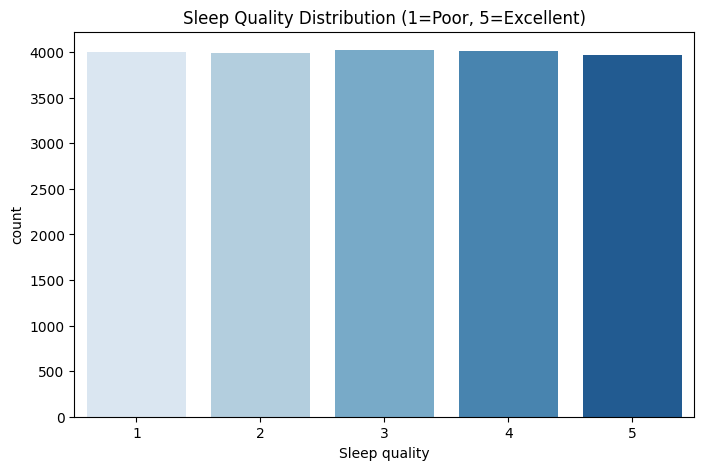

In [ ]:
# --- 2.3 Sleep Quality ---
print("\n--- 2.3 SLEEP QUALITY ANALYSIS ---")
print("Quality Distribution (1-5):")
print(data['Sleep quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='Sleep quality', data=data, palette='Blues')
ax.set_title('Sleep Quality Distribution (1=Poor, 5=Excellent)')
plt.show()


### 2.3 SLEEP DISORDER, WAKE UP, FEEL SLEEPY

Sleep Problems Frequencies:

Sleep disorder:
Sleep disorder
N    10069
Y     9931
Name: count, dtype: int64

Wake up during night:
Wake up during night
N    10000
Y    10000
Name: count, dtype: int64

Feel sleepy during day:
Feel sleepy during day
N    10178
Y     9822
Name: count, dtype: int64

Number of concurrent sleep problems per person:
Sleep_Problems_Count
0    2538
1    7658
2    7317
3    2487
Name: count, dtype: int64


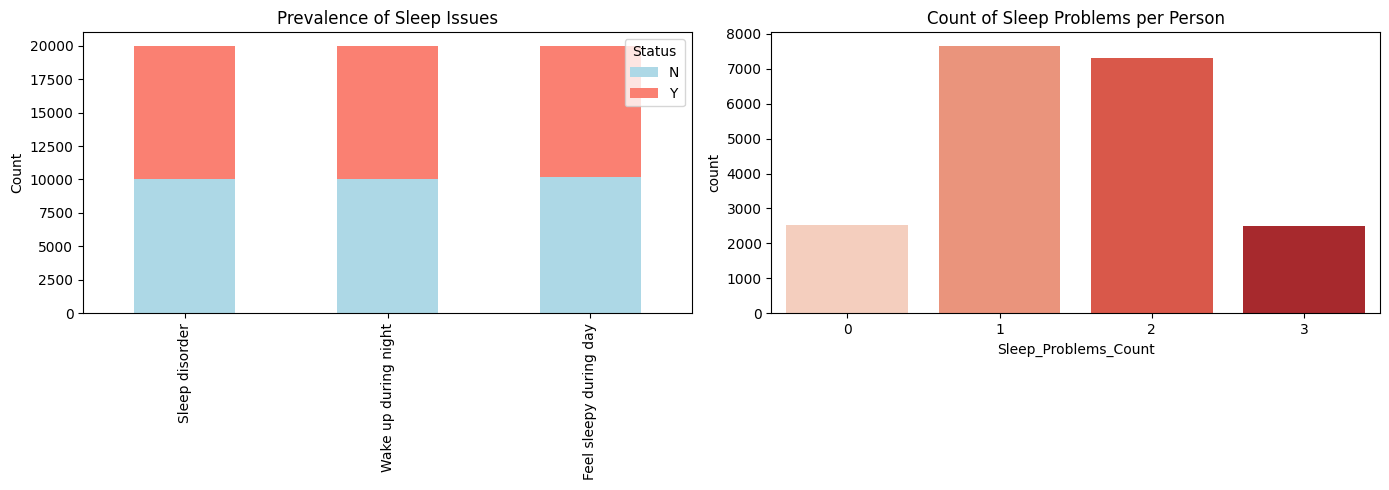

In [ ]:
problems = ['Sleep disorder', 'Wake up during night', 'Feel sleepy during day']

# Create a count of problems (0 to 3)
# Assuming 'Y' is Yes and 'N' is No. Adjust if your data uses different labels.
# Mapping Y->1, N->0 for calculation
for col in problems:
    data[f'{col}_num'] = data[col].map({'Y': 1, 'N': 0})

data['Sleep_Problems_Count'] = data[[f'{col}_num' for col in problems]].sum(axis=1)

print("Sleep Problems Frequencies:")
for col in problems:
    print(f"\n{col}:")
    print(data[col].value_counts())

print("\nNumber of concurrent sleep problems per person:")
print(data['Sleep_Problems_Count'].value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Stacked bar equivalent (Side-by-side counts)
prob_counts = pd.DataFrame()
for col in problems:
    prob_counts[col] = data[col].value_counts()
prob_counts.T.plot(kind='bar', stacked=True, ax=ax[0], color=['lightblue', 'salmon'])
ax[0].set_title('Prevalence of Sleep Issues')
ax[0].set_ylabel('Count')
ax[0].legend(title='Status')

sns.countplot(x='Sleep_Problems_Count', data=data, ax=ax[1], palette='Reds')
ax[1].set_title('Count of Sleep Problems per Person')
plt.tight_layout()
plt.show()


Dữ liệu cân bằng 1 cách nhân tạo

### 2.4 STREES LEVEL

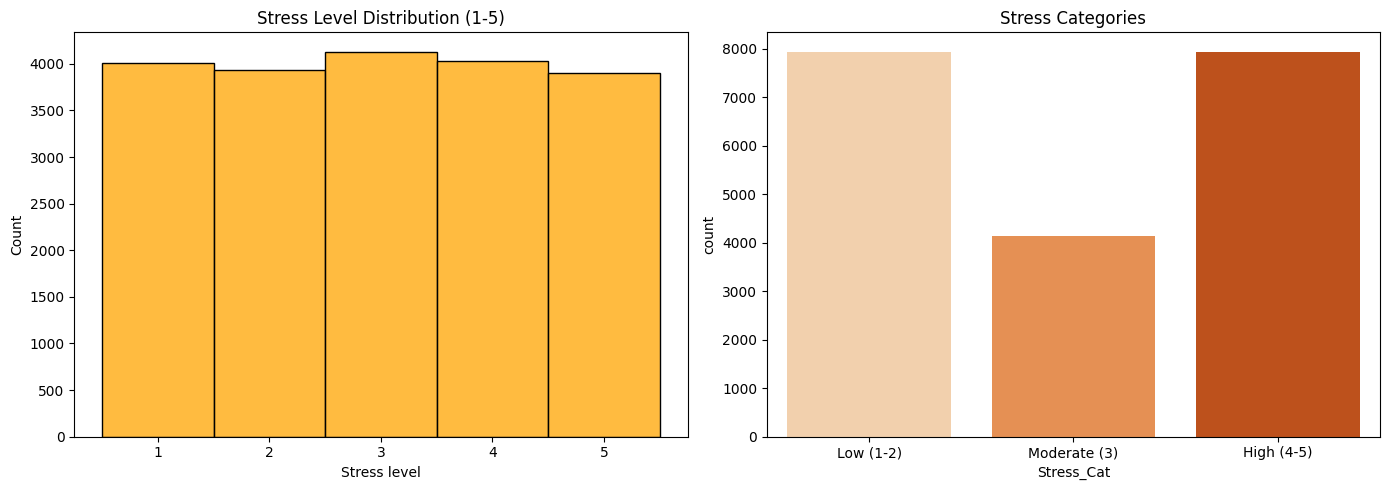

In [ ]:

# Classify Stress
data['Stress_Cat'] = pd.cut(data['Stress level'],
                            bins=[0, 2, 3, 5],
                            labels=['Low (1-2)', 'Moderate (3)', 'High (4-5)'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['Stress level'], bins=5, discrete=True, color='orange', ax=ax[0])
ax[0].set_title('Stress Level Distribution (1-5)')

sns.countplot(x='Stress_Cat', data=data, ax=ax[1], palette='Oranges')
ax[1].set_title('Stress Categories')
plt.tight_layout()
plt.show()

## PRASE 3: MỐI QUAN HỆ GIỮA CÁC BIẾN GIẤY NGỦ

### 2.5 SLEEP DURATION VỚI QUALITY

### 2.6 SLEEP QUALITY VỚI PROBLEMS

Spearman Correlation: -0.0069 (p=0.3284)


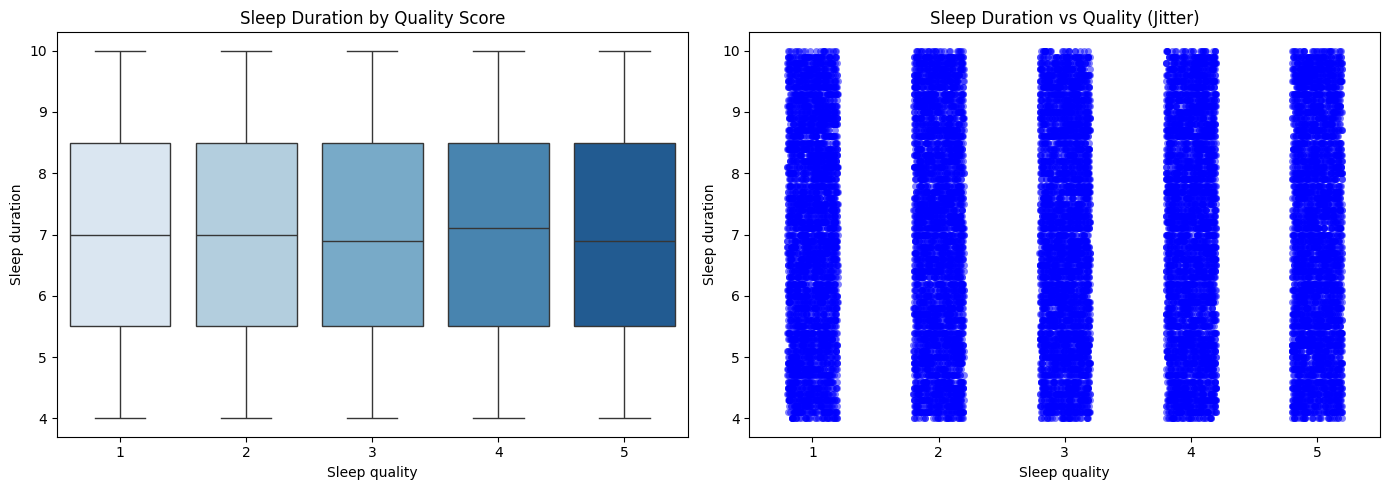

In [ ]:
corr_dur_qual, p_dur_qual = stats.spearmanr(data['Sleep duration'], data['Sleep quality'])
print(f"Spearman Correlation: {corr_dur_qual:.4f} (p={p_dur_qual:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Sleep quality', y='Sleep duration', data=data, ax=ax[0], palette='Blues')
ax[0].set_title('Sleep Duration by Quality Score')

# Jitter plot
sns.stripplot(x='Sleep quality', y='Sleep duration', data=data, ax=ax[1], alpha=0.5, jitter=0.2, color='blue')
ax[1].set_title('Sleep Duration vs Quality (Jitter)')
plt.tight_layout()
plt.savefig('team2_duration_vs_quality.png', dpi=300)
plt.show()


### 2.7 SLEEP VỚI STREES

Stress vs Quality Correlation: 0.0007
Stress vs Duration Correlation: -0.0061


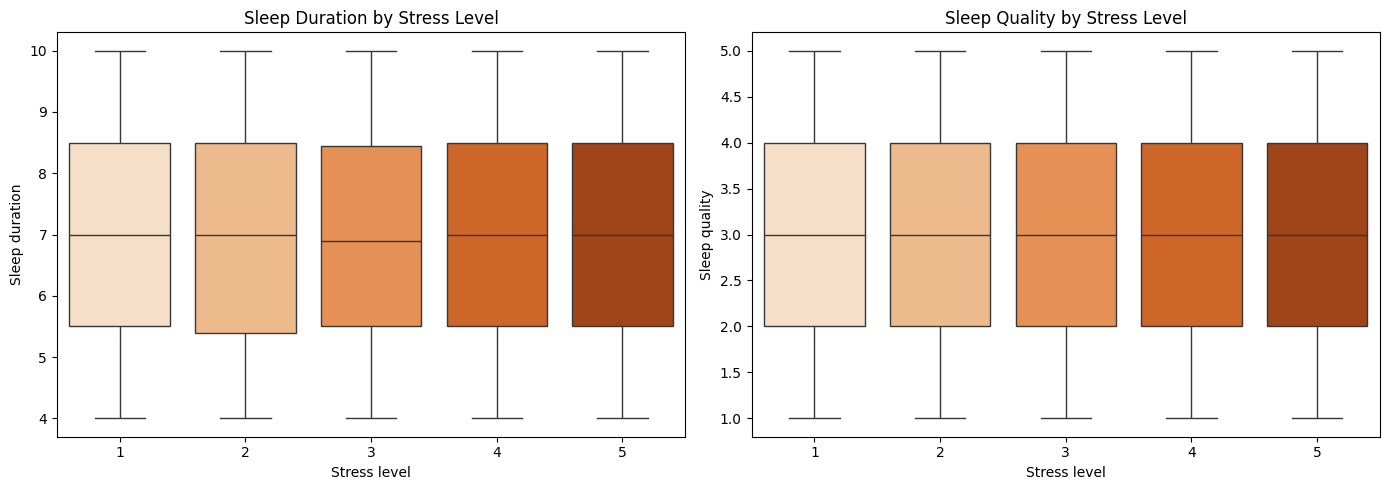

In [ ]:
corr_stress_qual, p_sq = stats.spearmanr(data['Stress level'], data['Sleep quality'])
corr_stress_dur, p_sd = stats.spearmanr(data['Stress level'], data['Sleep duration'])
print(f"Stress vs Quality Correlation: {corr_stress_qual:.4f}")
print(f"Stress vs Duration Correlation: {corr_stress_dur:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Stress level', y='Sleep duration', data=data, ax=ax[0], palette='Oranges')
ax[0].set_title('Sleep Duration by Stress Level')

sns.boxplot(x='Stress level', y='Sleep quality', data=data, ax=ax[1], palette='Oranges')
ax[1].set_title('Sleep Quality by Stress Level')
plt.tight_layout()
plt.savefig('team2_sleep_vs_stress.png', dpi=300)
plt.show()

## PRASE 4: PHÂN TÍCH VỚI DED

### 2.8 SLEEP DURATION - DED

Mean Duration - DED=Y: 7.00h
Mean Duration - DED=N: 7.00h
T-test: t=-0.1236, p=0.9016

Contingency Table - Sleep_Duration_Cat vs Dry Eye Disease:
Dry Eye Disease        N     Y
Sleep_Duration_Cat            
Severe Lack (<5h)   1091  2033
Lack (5-7h)         2329  4391
Normal (7-9h)       2300  4295
Excess (>9h)        1243  2318

Chi-square test: χ² = 0.1127, p-value = 0.9903


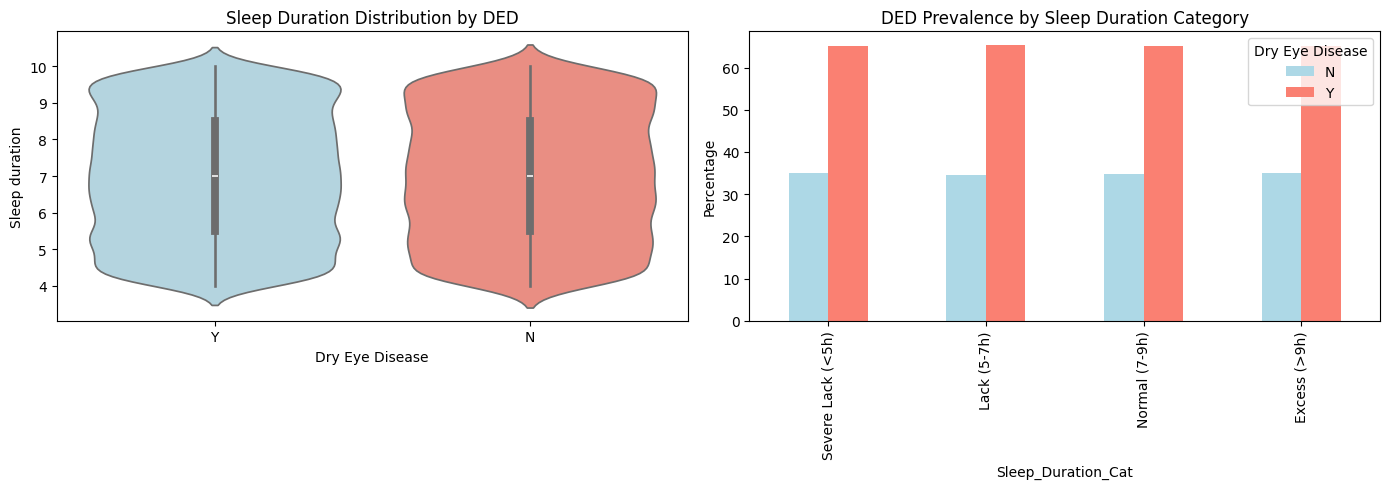

In [ ]:
dur_ded_y = data[data['Dry Eye Disease'] == 'Y']['Sleep duration']
dur_ded_n = data[data['Dry Eye Disease'] == 'N']['Sleep duration']
print(f"Mean Duration - DED=Y: {dur_ded_y.mean():.2f}h")
print(f"Mean Duration - DED=N: {dur_ded_n.mean():.2f}h")

t_dur, p_dur = ttest_ind(dur_ded_y, dur_ded_n)
print(f"T-test: t={t_dur:.4f}, p={p_dur:.4f}")

ct_dur, chi2_dur, p_ct_dur = chi_square_analysis(data, 'Sleep_Duration_Cat')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(x='Dry Eye Disease', y='Sleep duration', data=data, ax=ax[0], palette=['lightblue', 'salmon'])
ax[0].set_title('Sleep Duration Distribution by DED')

ct_dur_pct = ct_dur.div(ct_dur.sum(axis=1), axis=0) * 100
ct_dur_pct.plot(kind='bar', ax=ax[1], color=['lightblue', 'salmon'])
ax[1].set_title('DED Prevalence by Sleep Duration Category')
ax[1].set_ylabel('Percentage')
plt.tight_layout()
plt.show()

### 2.8 SEEP QUALITY - DED

Mann-Whitney U test: p=0.4809

Contingency Table - Sleep quality vs Dry Eye Disease:
Dry Eye Disease     N     Y
Sleep quality              
1                1379  2624
2                1389  2606
3                1408  2616
4                1379  2631
5                1408  2560

Chi-square test: χ² = 1.3971, p-value = 0.8447


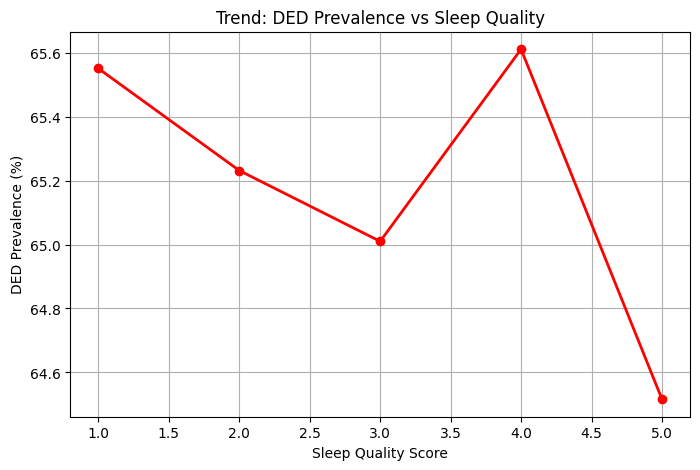

In [ ]:
# Using Mann-Whitney U for ordinal data
qual_ded_y = data[data['Dry Eye Disease'] == 'Y']['Sleep quality']
qual_ded_n = data[data['Dry Eye Disease'] == 'N']['Sleep quality']
u_stat, p_u = mannwhitneyu(qual_ded_y, qual_ded_n)
print(f"Mann-Whitney U test: p={p_u:.4f}")

ct_qual, chi2_qual, p_ct_qual = chi_square_analysis(data, 'Sleep quality')

fig, ax = plt.subplots(figsize=(8, 5))
ct_qual_pct = ct_qual.div(ct_qual.sum(axis=1), axis=0) * 100
ct_qual_pct['Y'].plot(kind='line', marker='o', color='red', linewidth=2)
ax.set_title('Trend: DED Prevalence vs Sleep Quality')
ax.set_ylabel('DED Prevalence (%)')
ax.set_xlabel('Sleep Quality Score')
ax.grid(True)
plt.show()

Không có giá trị dự đoán: Kết quả khẳng định Chất lượng giấc ngủ (tự đánh giá từ 1-5) không hề ảnh hưởng đến việc mắc bệnh Khô mắt hay không.

### 2.9 Sleep Disorder - DED

### 2.10 Wake up during night - DED

### 2.11  Feel sleepy during day - DED


Analyzing: Sleep disorder

Contingency Table - Sleep disorder vs Dry Eye Disease:
Dry Eye Disease     N     Y
Sleep disorder             
N                3518  6551
Y                3445  6486

Chi-square test: χ² = 0.1264, p-value = 0.7222
Odds Ratio: 0.9891 (95% CI: 0.9332 - 1.0483)

Analyzing: Wake up during night

Contingency Table - Wake up during night vs Dry Eye Disease:
Dry Eye Disease          N     Y
Wake up during night            
N                     3480  6520
Y                     3483  6517

Chi-square test: χ² = 0.0009, p-value = 0.9763
Odds Ratio: 1.0013 (95% CI: 0.9447 - 1.0613)

Analyzing: Feel sleepy during day

Contingency Table - Feel sleepy during day vs Dry Eye Disease:
Dry Eye Disease            N     Y
Feel sleepy during day            
N                       3566  6612
Y                       3397  6425

Chi-square test: χ² = 0.4278, p-value = 0.5131
Odds Ratio: 0.9803 (95% CI: 0.9249 - 1.0391)


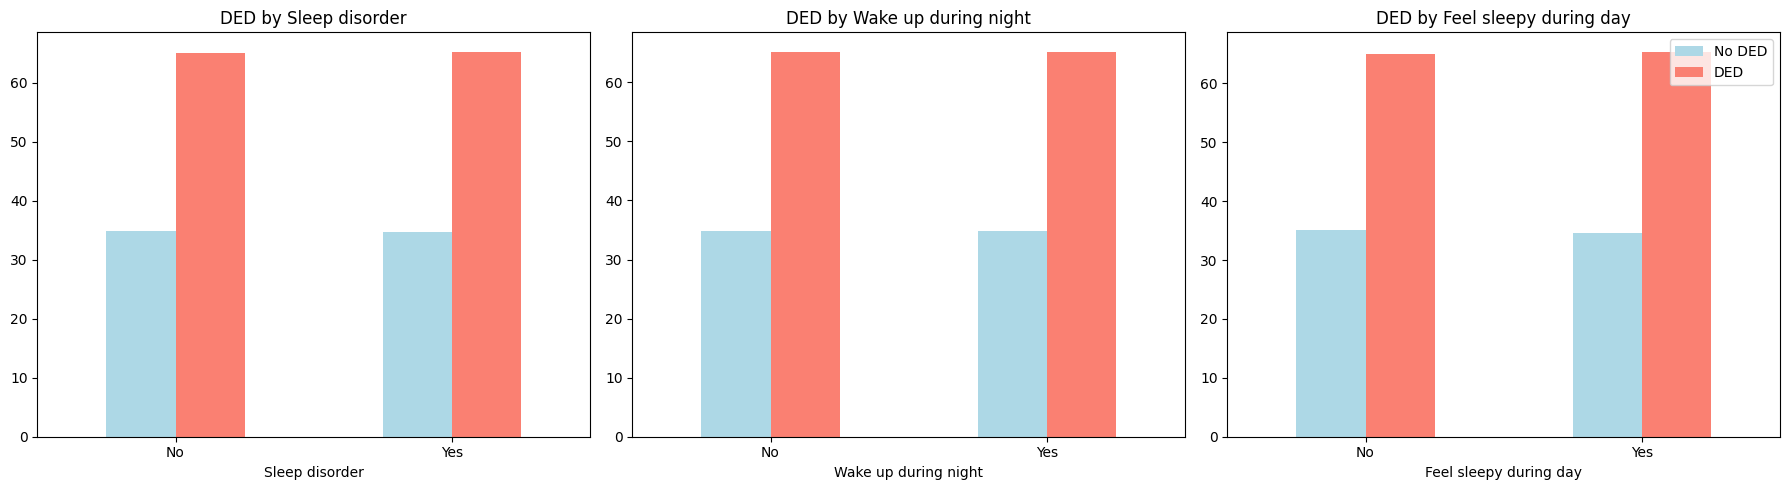

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(problems):
    print(f"\nAnalyzing: {col}")
    ct, chi2, p = chi_square_analysis(data, col)

    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax[i], color=['lightblue', 'salmon'], legend=False)
    ax[i].set_title(f'DED by {col}')
    ax[i].set_xticklabels(['No', 'Yes'], rotation=0)

    if i == 2: ax[i].legend(['No DED', 'DED'], loc='upper right')

plt.tight_layout()
plt.show()

### 2.13 Sleep Problems Count - DED


Contingency Table - Sleep_Problems_Count vs Dry Eye Disease:
Dry Eye Disease          N     Y
Sleep_Problems_Count            
0                      891  1647
1                     2695  4963
2                     2501  4816
3                      876  1611

Chi-square test: χ² = 2.0543, p-value = 0.5612


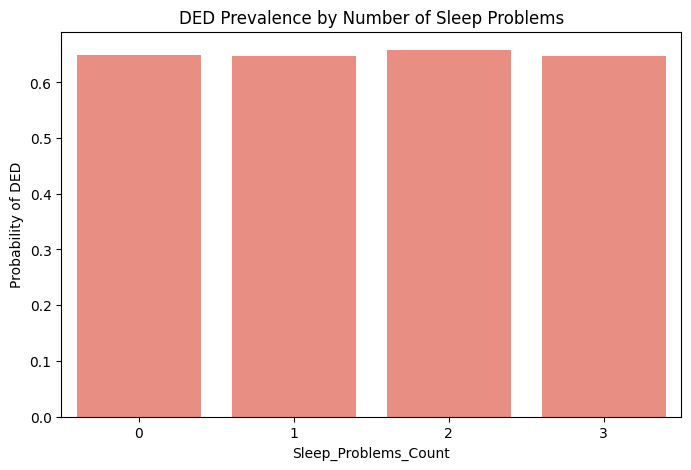

In [ ]:
ct_count, chi2_count, p_count = chi_square_analysis(data, 'Sleep_Problems_Count')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Sleep_Problems_Count', y='DED_numeric', data=data, ci=None, color='salmon')
ax.set_title('DED Prevalence by Number of Sleep Problems')
ax.set_ylabel('Probability of DED')
plt.show()

### 2.14 STRESS LEVEL

Mann-Whitney U (Stress): p=0.4395

Contingency Table - Stress level vs Dry Eye Disease:
Dry Eye Disease     N     Y
Stress level               
1                1398  2614
2                1398  2531
3                1418  2713
4                1421  2607
5                1328  2572

Chi-square test: χ² = 2.8375, p-value = 0.5854


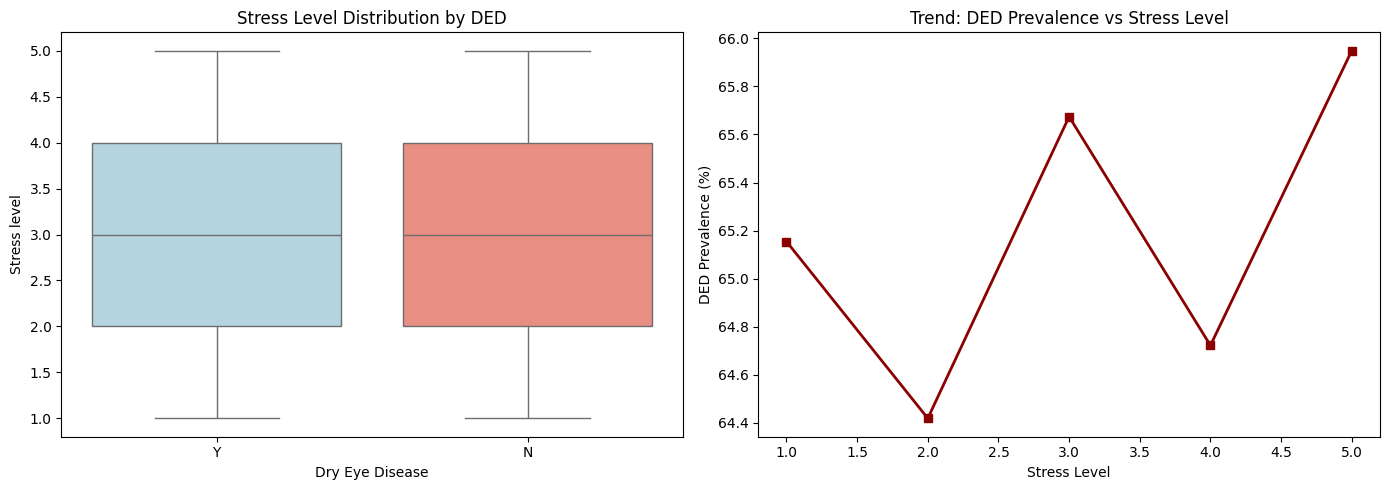

In [ ]:
stress_ded_y = data[data['Dry Eye Disease'] == 'Y']['Stress level']
stress_ded_n = data[data['Dry Eye Disease'] == 'N']['Stress level']
u_stress, p_stress = mannwhitneyu(stress_ded_y, stress_ded_n)
print(f"Mann-Whitney U (Stress): p={p_stress:.4f}")

ct_stress, chi2_stress, p_ct_stress = chi_square_analysis(data, 'Stress level')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Dry Eye Disease', y='Stress level', data=data, ax=ax[0], palette=['lightblue', 'salmon'])
ax[0].set_title('Stress Level Distribution by DED')

ct_stress_pct = ct_stress.div(ct_stress.sum(axis=1), axis=0) * 100
ct_stress_pct['Y'].plot(kind='line', marker='s', color='darkred', linewidth=2, ax=ax[1])
ax[1].set_title('Trend: DED Prevalence vs Stress Level')
ax[1].set_ylabel('DED Prevalence (%)')
ax[1].set_xlabel('Stress Level')
plt.tight_layout()
plt.show()

## PRASE 5: PHÂN TÍCH TỔNG HỢP

### 2.15 CORRELATION MATRIX


--- 2.16 CORRELATION MATRIX (SLEEP/STRESS) ---


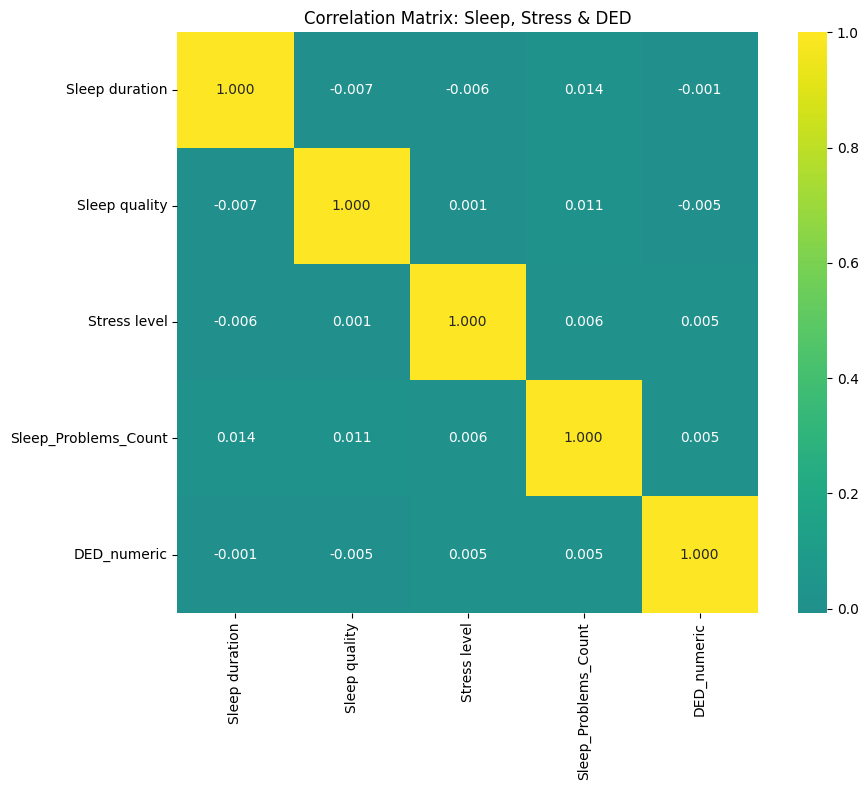

In [ ]:
print("\n--- 2.16 CORRELATION MATRIX (SLEEP/STRESS) ---")
sleep_vars = ['Sleep duration', 'Sleep quality', 'Stress level', 'Sleep_Problems_Count', 'DED_numeric']
corr_matrix_sleep = data[sleep_vars].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_sleep, annot=True, fmt='.3f', cmap='viridis', center=0, square=True)
plt.title('Correlation Matrix: Sleep, Stress & DED')
plt.tight_layout()
plt.savefig('team2_correlation_matrix.png', dpi=300)
plt.show()

Data KAGGLE